In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"_(\d+)MiB", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

roots = {
    "arms": Path("/users/zimooo2/tiering_solutions/times/arms"),
    "model": Path("/users/zimooo2/tiering_solutions/times/model"),
}

records: list[dict] = []
for label, root in roots.items():
    for path in sorted(root.glob("X*.time")):
        metrics = parse_time_file(path)
        log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
        records.append({
            "policy": label,
            "file": path.name,
            "MiB": extract_mib(path),
            **metrics,
            **log_metrics,
        })

df = pd.DataFrame(records)
df

,policy,file,MiB,real,user,sys,max_hugepage_equivalents_in_dram,max_base_pages_in_dram,hugepage_size_bytes
0,arms,XSBench_1000MiB.time,1000,549.425,0.078,0.170,180.5080,92420.0,2097152.0
1,arms,XSBench_1250MiB.time,1250,367.807,0.148,0.319,408.2170,209007.0,2097152.0
2,arms,XSBench_1500MiB.time,1500,429.257,0.157,0.365,346.4160,177365.0,2097152.0
3,arms,XSBench_1750MiB.time,1750,364.188,0.125,0.304,476.6540,244047.0,2097152.0
4,arms,XSBench_2000MiB.time,2000,334.878,0.117,0.281,727.6840,372574.0,2097152.0
5,arms,XSBench_2500MiB.time,2500,336.817,0.146,0.252,842.3180,431267.0,2097152.0
6,arms,XSBench_3000MiB.time,3000,338.066,0.115,0.277,1128.2600,577671.0,2097152.0
7,arms,XSBench_3500MiB.time,3500,335.199,0.123,0.266,1358.1100,695352.0,2097152.0
8,arms,XSBench_4000MiB.time,4000,335.972,0.118,0.286,1628.1100,833591.0,2097152.0
9,arms,XSBench_5000MiB.time,5000,335.595,0.128,0.275,2114.8300,1082793.0,2097152.0


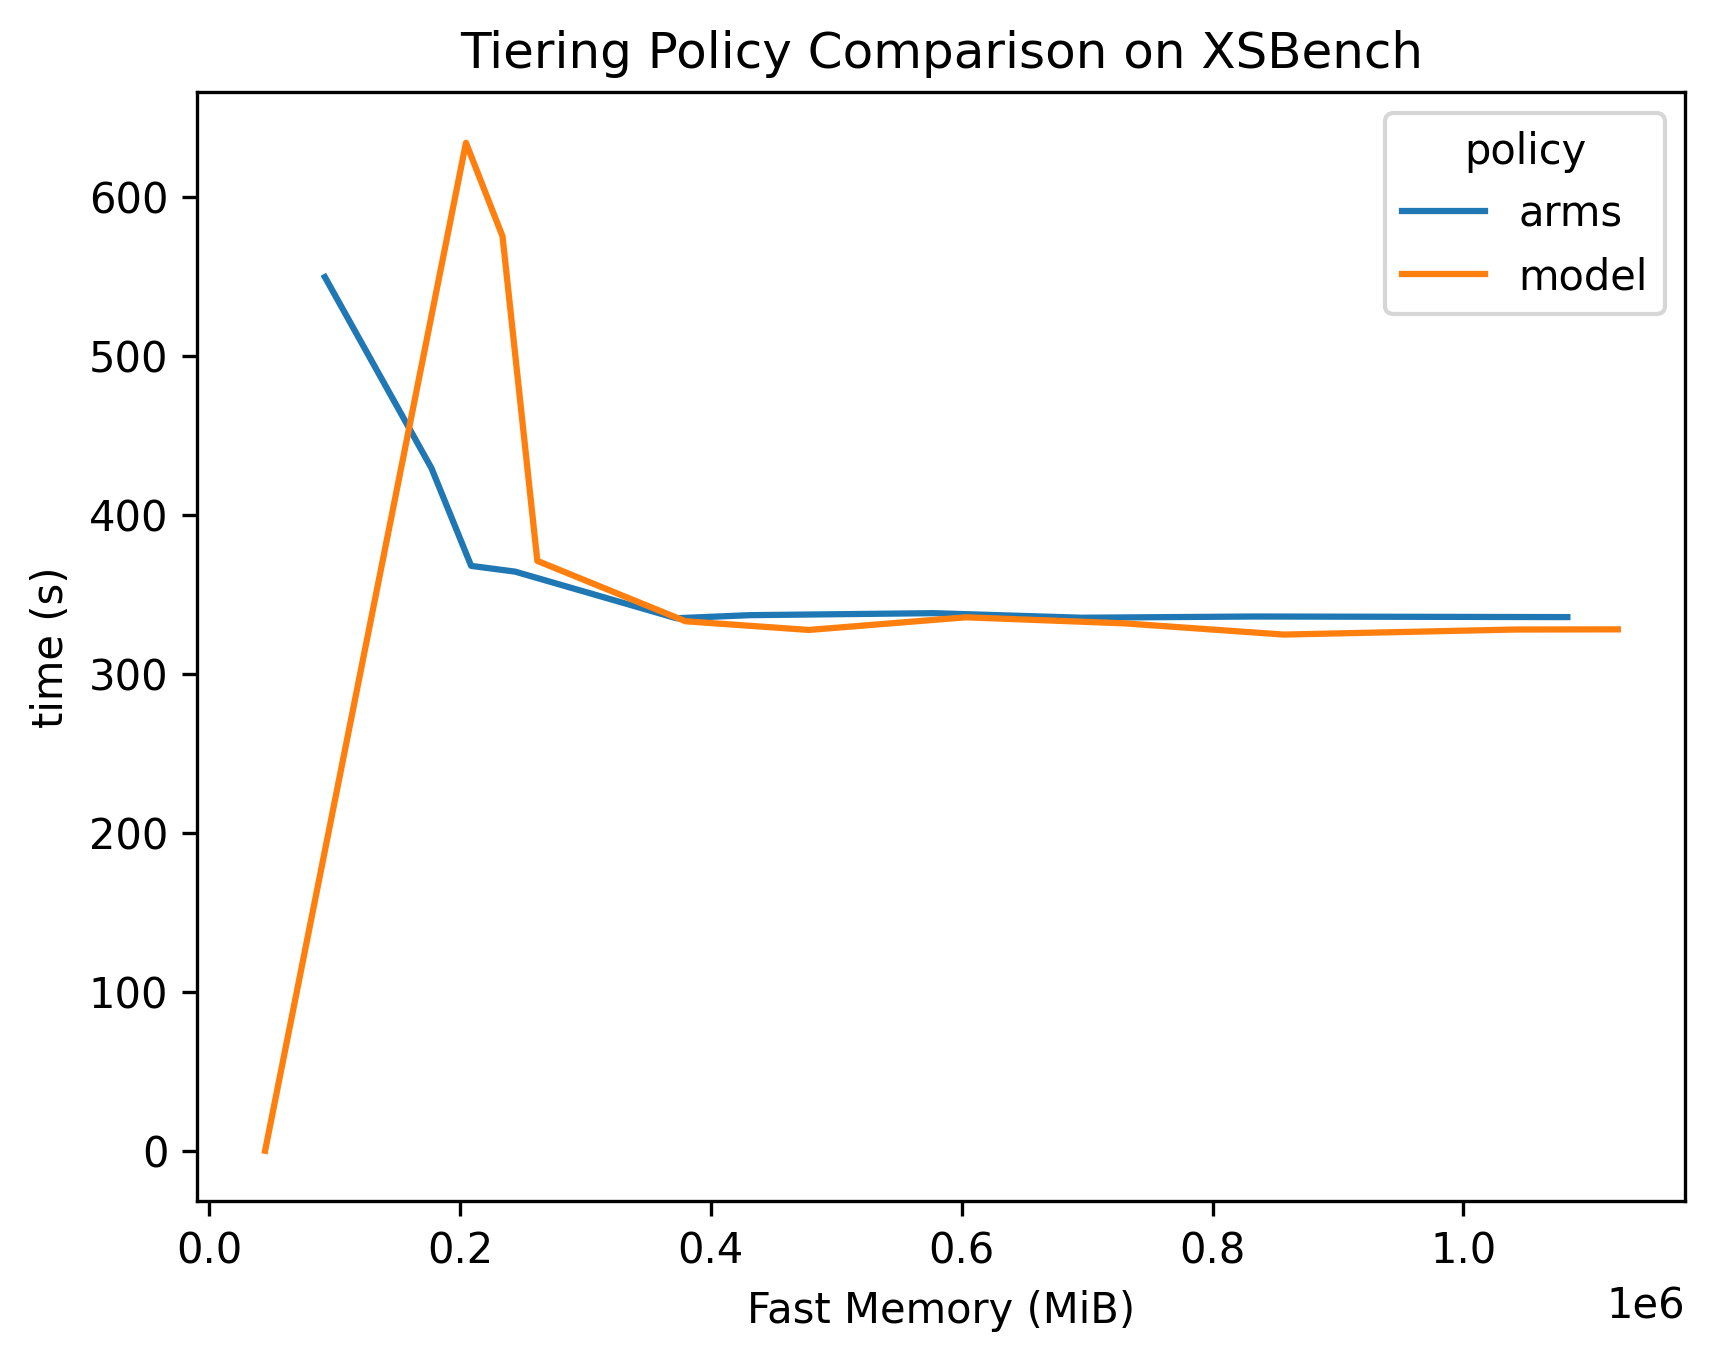

In [3]:
import matplotlib.pyplot as plt

sns.lineplot(df, x="max_base_pages_in_dram", y="real", hue="policy").set(
    ylabel="time (s)",
    xlabel="Fast Memory (MiB)",
    title="Tiering Policy Comparison on XSBench",
)
plt.gcf().set_dpi(300)